In [4]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.colors import LogNorm

In [5]:
from tractor import *
from tractor.galaxy import *
from tractor.sersic import *

In [6]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w'}
plt.rcParams.update(params)

In [12]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/dr10dev/misc/survey-ccds-dr10-v4-psfex-fwhm.fits'))
print(len(cat))
dr9 = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/survey-ccds-decam-dr9.fits.gz', columns=['expnum', 'ccdname', 'ccd_cuts', 'filter']))
print(len(dr9))

cat['ccd_id_str'] = np.char.add(np.array(cat['expnum']).astype(str), cat['ccdname'])
dr9['ccd_id_str'] = np.char.add(np.array(dr9['expnum']).astype(str), dr9['ccdname'])

mask = dr9['ccd_cuts']==0
dr9 = dr9[mask]
print(len(dr9))

cat = join(cat, dr9[['ccd_id_str', 'filter']], keys='ccd_id_str', join_type='inner')
print(len(cat))

ccd = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/survey-ccds-decam-dr9-trim.fits'))
cat = join(cat, ccd[['expnum', 'image_filename']])

cat_all = cat.copy()

15523579
6388340
4891222
4891222


In [14]:
mask = cat['ccdname']=='N10'
cat = cat[mask]

/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.8.2a/CP20190102/c4d_190103_015212_ooi_g_ls9-psfex.fits


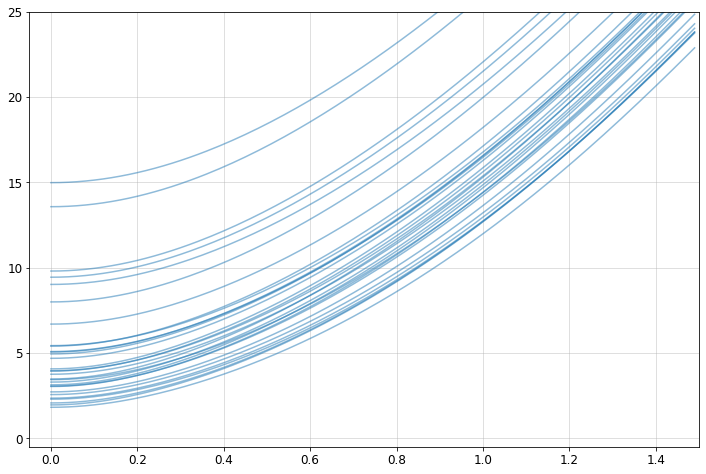

In [39]:
np.random.seed(929)
idx = np.random.choice(len(cat), size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    
    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(psfex_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

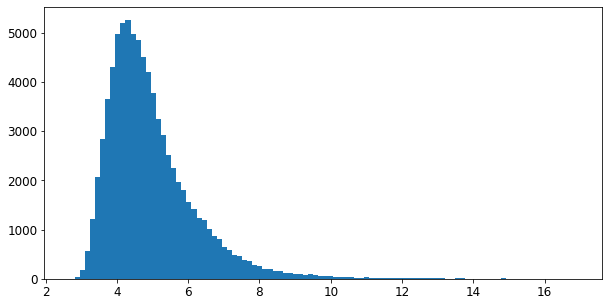

In [40]:
plt.figure(figsize=(10, 5))
plt.hist(cat['psf_fwhm'], 100)
plt.show()

138
/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.1/CP20171012/c4d_171013_043512_ooi_r_v1-psfex.fits


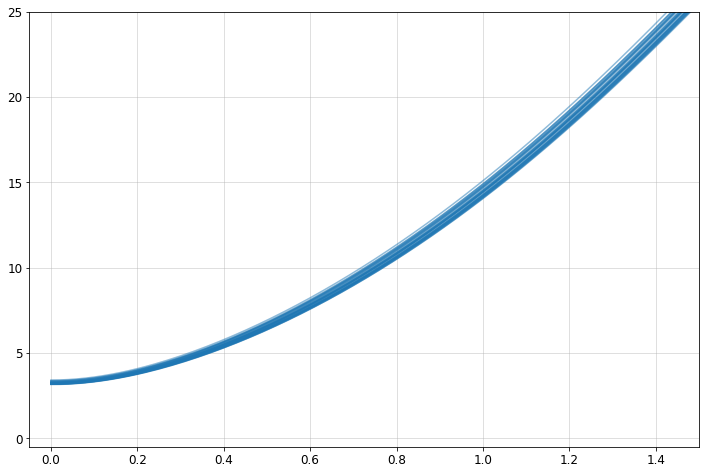

In [51]:
np.random.seed(929)
idx = np.where((cat['psf_fwhm']*0.262>1.199*0.96) & (cat['psf_fwhm']*0.262<1.2*0.96))[0]
print(len(idx))
idx = np.random.choice(idx, size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    
    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(psfex_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()

79
/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex/decam/CP/V4.8.2/CP20170718/c4d_170719_092939_ooi_z_ls9-psfex.fits


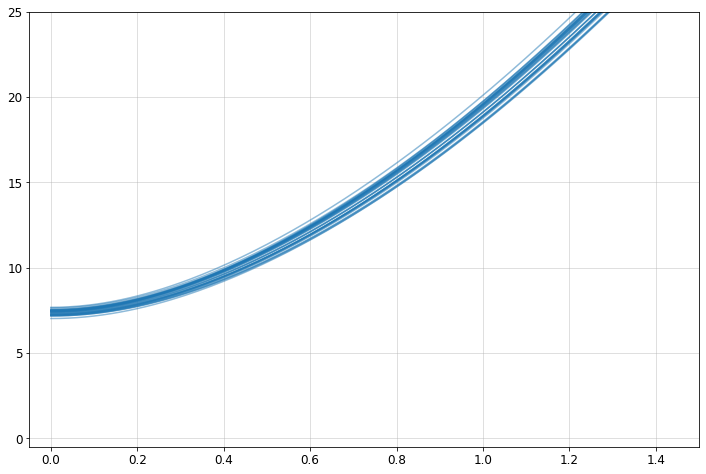

In [50]:
np.random.seed(929)
idx = np.where((cat['psf_fwhm']*0.262>1.797*0.96) & (cat['psf_fwhm']*0.262<1.8*0.96))[0]
print(len(idx))
idx = np.random.choice(idx, size=30, replace=False)

plt.figure(figsize=(12, 8))

for index in idx:
    image_filename = cat['image_filename'][index]
    psfex_filename = image_filename[:image_filename.find('.fits.fz')]+'-psfex.fits'
    psfex_path = os.path.join('/global/cfs/projectdirs/cosmo/work/legacysurvey/dr9/calib/psfex', psfex_filename)
    if index==idx[0]:
        print(psfex_path)
    psfex = Table(fitsio.read(psfex_path))
    ii = np.where(psfex['ccdname']==cat['ccdname'][index])[0][0]
    psfex_img = np.array(psfex['psf_mask'][ii][0])
    
    W, H = 41, 41

    shape_r_list = np.arange(0., 1.5, 0.01)
    nea_list = []

    for shape_r in shape_r_list:

        psffwhm = 1.2 / 0.262
        psfsigma = psffwhm / 2.3548
        # print('psfsigma', psfsigma)

        tim = Image(data=np.zeros((H,W)), invvar=np.ones((H,W))/(0.01**2),
                    psf=PixelizedPSF(psfex_img))


        source = ExpGalaxy(PixPos(20, 20), Flux(1.), GalaxyShape(shape_r/0.262, 1, 45.))
        tractor = Tractor([tim], [source])

        mod = tractor.getModelImage(0)

        nea = np.sum(mod)**2/np.sum(mod**2) # in unit of number of pixels
        # print('NEA = {:.2f} ({:.2f} arcsec^2)'.format(nea, nea*0.262**2))
        nea_list.append(nea)

    shape_r_list = np.array(shape_r_list)
    nea_list = np.array(nea_list)

    plt.plot(shape_r_list, nea_list*0.262**2, color='C0', alpha=0.5)

plt.axis([-0.05, 1.5, -0.5, 25])
plt.grid(alpha=0.5)
plt.show()